# Hipóteses de NPS - Safira

Implementação computacional das hipóteses descritas na seção 4.2.3 (`Hipóteses`) de
`documents/documentacao.md`:

- **Hipótese 1**: uma tripulação mal avaliada pode pesar tanto quanto um atraso grave
- **Hipótese 2**: o canal de compra revela um perfil de cliente com sensibilidades diferentes
- **Hipótese 4**: o detrator crônico
- **Hipótese 5**: o Cliente mais fidelizado é o menos tolerante à falha operacional

A base utilizada é `data/base_analitica.parquet`, a saída do pré-processamento que integra
NPS, perfil do Cliente e informação de viagem (ver `scripts/preprocessamento_nps.py` na
branch `develop`). Ela não é versionada neste repositório (ver `.gitignore` e a Política de
Privacidade da seção 4.1.8). Aponte `DATA_PATH`, abaixo, para o arquivo local ou para o
caminho no Google Drive quando este notebook for aberto no Colab.

**Correção em relação à versão anterior:** a primeira versão deste notebook rodava contra
uma base diferente, sem as colunas derivadas no pré-processamento (`ATRASO_CHEGADA`,
`CANAL_COMPRA`, `ID_GOLDENRECORD`, `TIER_VIAGEM`), e por isso registrava avisos de "coluna
não documentada". A base analítica atual já traz essas colunas prontas, então esta versão
recalcula as hipóteses do zero sobre os dados corretos, em vez de reaproveitar os números
da versão anterior.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## Configuração

Ajuste `DATA_PATH` se o arquivo estiver em outro local. O dicionário `COL` isola os nomes
de coluna num único lugar para que qualquer ajuste futuro não exija editar cada hipótese.

In [2]:
# Caminho da base. No Colab, monte o Drive e aponte para o arquivo, por exemplo:
#   from google.colab import drive
#   drive.mount("/content/drive")
#   DATA_PATH = "/content/drive/MyDrive/.../base_analitica.parquet"
DATA_PATH = "../data/base_analitica.parquet"

# Nomes de coluna da base analítica (saída do pré-processamento). ATRASO_CHEGADA,
# CANAL_COMPRA, ID_GOLDENRECORD e TIER_VIAGEM são colunas derivadas na integração das
# tabelas de NPS, perfil do Cliente e informação de viagem; não aparecem no dicionário
# de dados bruto da seção 4.1.3, que documenta apenas a base de pesquisa isolada.
COL = {
    "target": "NPS_PRINCIPAL",                  # -100 Detrator, 0 Neutro, 100 Promotor
    "comissarios": "NPS_COMISSARIOS",
    "pilotos": "NPS_PILOTOS",
    "atraso_saida": "ESTATISTICA_ATRASOSAIDA",  # atraso na PARTIDA, em minutos
    "atraso_chegada": "ATRASO_CHEGADA",         # atraso na CHEGADA, em minutos (derivado)
    "cancelamento": "CANCELAMENTO_VOO",
    "antecedencia_cancelamento": "ANTECEDENCIA_CANCELAMENTO",  # em dias, por definição da seção 4.1.3
    "canal_compra": "CANAL_COMPRA",
    "wifi": "NPS_WIFI",
    "entretenimento": "NPS_ENTRETENIMENTO",
    "embarque": "NPS_EMBARQUE",
    "cliente_id": "ID_GOLDENRECORD",            # identificador do Cliente ao longo do tempo
    "data_voo": "DATA_STD_CONVERTIDA",          # DATA_STD já convertida para datetime no pré-processamento
    "tier_viagem": "TIER_VIAGEM",
    "rota": "BASE_AIRPORTLEG",                  # sequência de aeroportos da jornada, separados por "/"
    "tempo_voo": "TEMPO_VOO",
}

LIMIAR_NOTA_NEGATIVA = 6   # notas 0 a 6 na escala 0-10, mesmo corte de Detrator do NPS_PRINCIPAL
LIMIAR_NOTA_POSITIVA = 9   # notas 9 e 10, mesmo corte de Promotor do NPS_PRINCIPAL
LIMIAR_ATRASO_GRAVE_MIN = 120

In [3]:
df = pd.read_parquet(DATA_PATH)
print(f"{len(df):,} registros carregados de {DATA_PATH}")

def checar_colunas(colunas_necessarias, contexto):
    # Mantido como checagem defensiva: se alguém rodar este notebook contra uma
    # exportação parcial da base analítica, o aviso aponta exatamente a coluna que
    # falta em vez de estourar um KeyError no meio da hipótese.
    faltantes = [c for c in colunas_necessarias if c not in df.columns]
    if faltantes:
        print(f"[{contexto}] colunas ausentes na base carregada: {faltantes}")
        print(f"[{contexto}] ajuste o dicionário COL para os nomes reais antes de continuar.")
    return not faltantes

# DATA_STD_CONVERTIDA já sai como datetime do pré-processamento; a conversão só roda
# se alguém apontar DATA_PATH para uma base mais antiga que ainda não passou por ele.
nome_data_voo = COL["data_voo"]
if nome_data_voo in df.columns and not pd.api.types.is_datetime64_any_dtype(df[nome_data_voo]):
    df[nome_data_voo] = pd.to_datetime(df[nome_data_voo], dayfirst=True, errors="coerce")

484,915 registros carregados de ../data/base_analitica.parquet


## Funções auxiliares

Reaproveitadas por mais de uma hipótese: a definição de Detrator, a leitura de
`CANCELAMENTO_VOO` e o recorte de "voo perfeito" (pontual e sem cancelamento) que isola
problemas de tripulação e de canal de compra de qualquer influência operacional.

In [4]:
def to_bool(serie):
    # CANCELAMENTO_VOO já vem como bool na base analítica atual, mas a função
    # trata também o formato de texto Sim/Não: serie.astype(bool) direto é uma
    # armadilha aqui, porque qualquer string não vazia é truthy em Python, então
    # "Nao" também viraria True. Preferimos avisar sobre um valor não reconhecido a
    # deixá-lo virar True silenciosamente.
    if pd.api.types.is_bool_dtype(serie):
        return serie.fillna(False)
    if pd.api.types.is_numeric_dtype(serie):
        return serie.fillna(0).astype(bool)
    normalizada = serie.astype(str).str.strip().str.lower()
    verdadeiros = {"true", "1", "sim", "yes", "y", "verdadeiro"}
    falsos = {"false", "0", "nao", "não", "no", "n", "falso"}
    convertida = normalizada.map(lambda v: True if v in verdadeiros else (False if v in falsos else None))
    nao_reconhecidos = sorted(set(normalizada[convertida.isna() & serie.notna()]))
    if nao_reconhecidos:
        print(f"[to_bool] valores não reconhecidos em '{serie.name}', tratados como False: {nao_reconhecidos}")
    return convertida.fillna(False).astype(bool)

def is_detrator(serie_nps):
    return serie_nps.eq(-100)

def voos_pontuais_sem_cancelamento(base):
    # Isola qualquer influência operacional (atraso, cancelamento) para que o efeito
    # medido em cada hipótese venha só da variável de interesse (tripulação, canal etc.).
    pontual = base[COL["atraso_saida"]] <= 0
    sem_cancelamento = ~to_bool(base[COL["cancelamento"]])
    return base[pontual & sem_cancelamento].copy()

def taxa_detratores(base, coluna_grupo=None):
    alvo = is_detrator(base[COL["target"]])
    if coluna_grupo is None:
        return alvo.mean()
    return base.assign(_detrator=alvo).groupby(coluna_grupo, observed=True)["_detrator"].mean()

## Hipótese 1: uma tripulação mal avaliada pode pesar tanto quanto um atraso grave

Isola voos pontuais e sem cancelamento, compara a taxa de detratores entre avaliações
negativas e positivas de comissários e pilotos, e contrasta com a taxa de detratores no
pior cenário puramente operacional da base (atraso na chegada acima de 120 minutos).

In [5]:
if checar_colunas(
    [COL["comissarios"], COL["pilotos"], COL["atraso_saida"], COL["cancelamento"],
     COL["atraso_chegada"], COL["target"]],
    "Hipótese 1",
):
    base_limpa = voos_pontuais_sem_cancelamento(df)
    print(f"Voos pontuais e sem cancelamento: {len(base_limpa):,} de {len(df):,}")

    def taxa_por_avaliacao(base, coluna_nota):
        # Compara os dois extremos da escala (0-6 vs. 9-10) em vez de correlacionar a
        # nota diretamente com a detração: é a mesma leitura da tabela de detratores
        # do NPS_PRINCIPAL, aplicada a uma sub-nota da jornada.
        notas = base[coluna_nota].dropna()
        negativa = base.loc[notas[notas <= LIMIAR_NOTA_NEGATIVA].index]
        positiva = base.loc[notas[notas >= LIMIAR_NOTA_POSITIVA].index]
        return taxa_detratores(negativa), taxa_detratores(positiva), len(negativa), len(positiva)

    for rotulo, coluna in [("Comissários", COL["comissarios"]), ("Pilotos", COL["pilotos"])]:
        neg, pos, n_neg, n_pos = taxa_por_avaliacao(base_limpa, coluna)
        print(f"{rotulo}: avaliação negativa {neg:.1%} (n={n_neg:,}), "
              f"avaliação positiva {pos:.1%} (n={n_pos:,})")

    # O contraponto usa a base inteira (não só voos pontuais): queremos o pior cenário
    # operacional que a malha realmente produz, não um recorte que já excluiria atraso.
    atraso_grave = df[df[COL["atraso_chegada"]] > LIMIAR_ATRASO_GRAVE_MIN]
    print(f"\nAtraso na chegada acima de {LIMIAR_ATRASO_GRAVE_MIN} min "
          f"({len(atraso_grave):,} voos): {taxa_detratores(atraso_grave):.1%} de detratores")

Voos pontuais e sem cancelamento: 238,104 de 484,915
Comissários: avaliação negativa 46.6% (n=25,355), avaliação positiva 7.5% (n=160,765)
Pilotos: avaliação negativa 48.4% (n=16,281), avaliação positiva 9.4% (n=165,778)

Atraso na chegada acima de 120 min (20,099 voos): 75.7% de detratores


## Hipótese 2: o canal de compra revela um perfil de cliente com sensibilidades diferentes

Mesma base de voos pontuais e sem cancelamento. Primeiro compara a taxa de detratores por
canal de compra; depois, dentro de cada canal, mede o quanto uma avaliação negativa de
wifi/entretenimento e de comissários/embarque eleva a taxa de detratores em relação a uma
avaliação positiva.

In [6]:
if checar_colunas(
    [COL["canal_compra"], COL["atraso_saida"], COL["cancelamento"], COL["target"]],
    "Hipótese 2",
):
    base_limpa = voos_pontuais_sem_cancelamento(df)
    taxa_por_canal = taxa_detratores(base_limpa, COL["canal_compra"]).sort_values()
    print("Taxa de detratores por canal de compra (voos pontuais e sem cancelamento):")
    print(taxa_por_canal.apply(lambda v: f"{v:.1%}"))

    def efeito_avaliacao_negativa(base, coluna_nota, canal):
        # Diferença de taxa (negativo menos positivo) em vez de razão: com canais de
        # baixo volume (CALLCENTER, AEROPORTO, OTHER) uma razão amplificaria ruído de
        # amostra pequena; a diferença em pontos percentuais é mais estável para comparar
        # entre canais com "n" tão desiguais.
        base_canal = base[base[COL["canal_compra"]] == canal]
        notas = base_canal[coluna_nota].dropna()
        negativa = base_canal.loc[notas[notas <= LIMIAR_NOTA_NEGATIVA].index]
        positiva = base_canal.loc[notas[notas >= LIMIAR_NOTA_POSITIVA].index]
        if len(negativa) == 0 or len(positiva) == 0:
            return np.nan
        return taxa_detratores(negativa) - taxa_detratores(positiva)

    for canal in taxa_por_canal.index:
        print(f"\n{canal}:")
        for rotulo, coluna in [
            ("wifi", COL["wifi"]),
            ("entretenimento", COL["entretenimento"]),
            ("comissários", COL["comissarios"]),
            ("embarque", COL["embarque"]),
        ]:
            efeito = efeito_avaliacao_negativa(base_limpa, coluna, canal)
            if pd.notna(efeito):
                print(f"  variação na detração ({rotulo} negativo vs. positivo): {efeito:+.1%}")
            else:
                print(f"  {rotulo}: dados insuficientes nesse canal")

Taxa de detratores por canal de compra (voos pontuais e sem cancelamento):
CANAL_COMPRA
WEB           11.6%
AGENCY        12.7%
MOBILE        13.0%
CALLCENTER    14.1%
AEROPORTO     18.7%
OTHER         22.7%
Name: _detrator, dtype: str

WEB:
  variação na detração (wifi negativo vs. positivo): +12.1%
  variação na detração (entretenimento negativo vs. positivo): +13.2%
  variação na detração (comissários negativo vs. positivo): +37.4%
  variação na detração (embarque negativo vs. positivo): +32.6%

AGENCY:
  variação na detração (wifi negativo vs. positivo): +12.9%
  variação na detração (entretenimento negativo vs. positivo): +14.6%
  variação na detração (comissários negativo vs. positivo): +39.8%
  variação na detração (embarque negativo vs. positivo): +34.8%

MOBILE:
  variação na detração (wifi negativo vs. positivo): +14.6%
  variação na detração (entretenimento negativo vs. positivo): +14.8%
  variação na detração (comissários negativo vs. positivo): +39.0%
  variação na detraçã

## Hipótese 4: o detrator crônico

Requer um identificador de Cliente estável entre respostas (`COL["cliente_id"]`) para
ordenar o histórico por `COL["data_voo"]` e comparar cada resposta com a resposta anterior
do mesmo Cliente. Reproduz os três testes do quadro da seção 4.2.3 (concentração com
qui-quadrado 2x2, predição por taxas condicionais e resistência a controles operacionais
progressivos) além da regressão logística final.

In [7]:
if checar_colunas(
    [COL["cliente_id"], COL["data_voo"], COL["target"], COL["atraso_saida"], COL["cancelamento"]],
    "Hipótese 4",
):
    # Sem ID_GOLDENRECORD não há como saber a quem a resposta pertence, e sem
    # DATA_STD_CONVERTIDA não há como saber qual resposta veio antes: as duas colunas
    # têm nulos na base (cerca de 24,7% em DATA_STD_CONVERTIDA) e removê-los aqui, antes
    # de ordenar, evita que uma data ausente distorça a posição de um Cliente na fila.
    base_h4 = df.dropna(subset=[COL["cliente_id"], COL["data_voo"]]).copy()
    print(f"Respostas com Cliente e data identificados: {len(base_h4):,} de {len(df):,} "
          f"({len(base_h4) / len(df):.1%})")

    historico = base_h4.sort_values([COL["cliente_id"], COL["data_voo"]]).copy()
    historico["_detrator"] = is_detrator(historico[COL["target"]])
    historico["_pontual"] = (historico[COL["atraso_saida"]] <= 0) & (
        ~to_bool(historico[COL["cancelamento"]])
    )
    historico["_detrator_anterior"] = historico.groupby(COL["cliente_id"])["_detrator"].shift(1)
    historico["_pontual_anterior"] = historico.groupby(COL["cliente_id"])["_pontual"].shift(1)

    respostas_com_historico = historico[historico["_detrator_anterior"].notna()].copy()
    respostas_com_historico["_detrator_anterior"] = respostas_com_historico["_detrator_anterior"].astype(bool)

    print(
        f"Respostas com pelo menos uma resposta anterior do mesmo Cliente: "
        f"{len(respostas_com_historico):,} de {len(historico):,} "
        f"({len(respostas_com_historico) / len(historico):.1%})"
    )

Respostas com Cliente e data identificados: 364,812 de 484,915 (75.2%)
Respostas com pelo menos uma resposta anterior do mesmo Cliente: 51,654 de 364,812 (14.2%)


In [8]:
# Teste 1: concentração, entre Clientes com exatamente duas respostas
contagem_por_cliente = historico.groupby(COL["cliente_id"]).size()
clientes_com_duas = contagem_por_cliente[contagem_por_cliente == 2].index
duplas = historico[historico[COL["cliente_id"]].isin(clientes_com_duas)]

primeira = duplas.groupby(COL["cliente_id"])["_detrator"].first()
segunda = duplas.groupby(COL["cliente_id"])["_detrator"].last()
tabela_2x2 = pd.crosstab(primeira, segunda)

chi2, p_valor, gl, esperado = stats.chi2_contingency(tabela_2x2, correction=False)
esperado_df = pd.DataFrame(esperado, index=tabela_2x2.index, columns=tabela_2x2.columns)

print(f"Clientes com exatamente duas respostas: {len(clientes_com_duas):,}")
print("\nTabela observada (linha = primeira resposta, coluna = segunda resposta):")
print(tabela_2x2)
print("\nTabela esperada sob independência:")
print(esperado_df.round(1))
print(f"\nqui-quadrado = {chi2:.1f}; gl = {gl}; p = {p_valor:.3g}")

Clientes com exatamente duas respostas: 26,318

Tabela observada (linha = primeira resposta, coluna = segunda resposta):
_detrator  False  True 
_detrator              
False      17524   3565
True        2685   2544

Tabela esperada sob independência:
_detrator       False      True 
_detrator                       
False     16,193.8000 4,895.2000
True       4,015.2000 1,213.8000

qui-quadrado = 2369.3; gl = 1; p = 0


In [9]:
# Teste 2: predição
taxa_pos = respostas_com_historico.loc[respostas_com_historico["_detrator_anterior"], "_detrator"].mean()
taxa_neg = respostas_com_historico.loc[~respostas_com_historico["_detrator_anterior"], "_detrator"].mean()

print(f"Taxa de detração | detratou na resposta anterior: {taxa_pos:.1%}")
print(f"Taxa de detração | não detratou na resposta anterior: {taxa_neg:.1%}")
print(f"Razão: {taxa_pos / taxa_neg:.1f}x")

# Teste 3: resistência a controles operacionais progressivos
def razao_detratou_vs_nao(base):
    pos = base.loc[base["_detrator_anterior"], "_detrator"].mean()
    neg = base.loc[~base["_detrator_anterior"], "_detrator"].mean()
    return pos, neg, pos / neg

voo_atual_perfeito = respostas_com_historico[respostas_com_historico["_pontual"]]
ambos_perfeitos = respostas_com_historico[
    respostas_com_historico["_pontual"] & respostas_com_historico["_pontual_anterior"].fillna(False)
]

# Se a razão caísse ao remover as causas operacionais, o efeito seria explicado pelo
# voo, não pela pessoa; o teste é justamente ver se ela sobe em vez de cair.
print()
for rotulo, base in [
    ("Todas as respostas com histórico", respostas_com_historico),
    ("Voo atual pontual e sem cancelamento", voo_atual_perfeito),
    ("Voo atual e anterior pontuais e sem cancelamento", ambos_perfeitos),
]:
    pos, neg, razao = razao_detratou_vs_nao(base)
    print(f"{rotulo} (n={len(base):,}): {razao:.1f}x ({pos:.1%} vs. {neg:.1%})")

Taxa de detração | detratou na resposta anterior: 46.8%
Taxa de detração | não detratou na resposta anterior: 15.9%
Razão: 2.9x

Todas as respostas com histórico (n=51,654): 2.9x (46.8% vs. 15.9%)
Voo atual pontual e sem cancelamento (n=27,345): 3.8x (35.9% vs. 9.4%)
Voo atual e anterior pontuais e sem cancelamento (n=14,295): 4.3x (41.3% vs. 9.6%)


In [10]:
# Regressão logística: detrator ~ detratou_antes + atraso + cancelamento
# Controla pelas duas principais falhas operacionais para isolar o efeito do histórico
# do Cliente do efeito de o voo atual simplesmente ter sido pior.
modelo_dados = respostas_com_historico.dropna(subset=[COL["atraso_saida"], COL["cancelamento"]]).copy()
modelo_dados["_cancelado"] = to_bool(modelo_dados[COL["cancelamento"]]).astype(int)
modelo_dados["_detrator_anterior_int"] = modelo_dados["_detrator_anterior"].astype(int)
modelo_dados["_detrator_int"] = modelo_dados["_detrator"].astype(int)

X = sm.add_constant(modelo_dados[["_detrator_anterior_int", COL["atraso_saida"], "_cancelado"]])
y = modelo_dados["_detrator_int"]
modelo_logit = sm.Logit(y, X).fit(disp=False)
print(modelo_logit.summary2().tables[1])

coef = modelo_logit.params["_detrator_anterior_int"]
ic_inf, ic_sup = modelo_logit.conf_int().loc["_detrator_anterior_int"]
p_valor_coef = modelo_logit.pvalues["_detrator_anterior_int"]

print(
    f"\nOdds ratio (detratou na resposta anterior): {np.exp(coef):.2f} "
    f"[IC 95%: {np.exp(ic_inf):.2f} - {np.exp(ic_sup):.2f}], p = {p_valor_coef:.3g}"
)

                          Coef.  Std.Err.         z  P>|z|  [0.025  0.975]
const                   -2.1086    0.0165 -127.7585 0.0000 -2.1410 -2.0763
_detrator_anterior_int   1.5911    0.0254   62.6139 0.0000  1.5413  1.6409
ESTATISTICA_ATRASOSAIDA  0.0209    0.0004   51.4787 0.0000  0.0201  0.0216
_cancelado               1.1754    0.0399   29.4877 0.0000  1.0973  1.2535

Odds ratio (detratou na resposta anterior): 4.91 [IC 95%: 4.67 - 5.16], p = 0


## Hipótese 5: o Cliente mais fidelizado é o menos tolerante à falha operacional

Testa se o efeito do atraso na partida sobre a taxa de detratores muda conforme o tier
de fidelidade do Cliente (`COL["tier_viagem"]`). O atraso é discretizado na mesma
taxonomia da seção 4.2.1 (`_faixa_atraso`: sem atraso, 15-60 min, 61-120 min, mais de
120 min).

- **H0**: a taxa de detratores por faixa de atraso é independente do tier de fidelidade
  (tier e faixa de atraso agem apenas de forma aditiva sobre a detração).
- **H1**: existe interação, e o efeito do atraso sobre a detração é maior nos tiers mais
  altos.
- **alfa = 0,05**

In [11]:
if checar_colunas(
    [COL["tier_viagem"], COL["atraso_saida"], COL["target"]],
    "Hipótese 5",
):
    ORD_ATRASO_H5 = ["a. Sem Atraso", "b. 15m - 60m", "c. 61m - 120m", "d. Mais de 120m"]

    def faixa_atraso(minutos):
        # Mesma discretização da seção 4.2.1: bandas fechadas até 120 min e uma
        # faixa aberta acima disso.
        banda = np.select(
            [minutos < 15, minutos <= 60, minutos <= 120],
            ORD_ATRASO_H5[:3],
            default=ORD_ATRASO_H5[3],
        )
        return pd.Categorical(banda, categories=ORD_ATRASO_H5, ordered=True)

    base_h5 = df.dropna(subset=[COL["tier_viagem"], COL["atraso_saida"], COL["target"]]).copy()
    base_h5["_faixa_atraso"] = faixa_atraso(base_h5[COL["atraso_saida"]])
    base_h5["_detrator"] = is_detrator(base_h5[COL["target"]]).astype(int)

    tabela_n = pd.crosstab(base_h5[COL["tier_viagem"]], base_h5["_faixa_atraso"])
    tabela_taxa = pd.crosstab(
        base_h5[COL["tier_viagem"]], base_h5["_faixa_atraso"],
        values=base_h5["_detrator"], aggfunc="mean",
    )

    print(
        f"Respostas com tier e faixa de atraso definidos: {len(base_h5):,} de {len(df):,} "
        f"({len(base_h5) / len(df):.1%})"
    )
    print("\nTamanho de cada célula tier x faixa de atraso:")
    print(tabela_n)

    celulas_pequenas = int((tabela_n < 30).sum().sum())
    if celulas_pequenas:
        print(
            f"\n[aviso] {celulas_pequenas} célula(s) tier x faixa de atraso com menos de "
            "30 respostas: a estimativa de interação nessas células é instável."
        )

    print("\nTaxa de detratores (%) por tier e faixa de atraso:")
    print(tabela_taxa.mul(100).round(1))

Respostas com tier e faixa de atraso definidos: 484,915 de 484,915 (100.0%)

Tamanho de cada célula tier x faixa de atraso:
_faixa_atraso    a. Sem Atraso  b. 15m - 60m  c. 61m - 120m  d. Mais de 120m
TIER_VIAGEM                                                                 
AZUL FIDELIDADE         192352         38719           8885             4162
AZUL ONE                   146            32              9                2
DIAMANTE                 57440         12344           3457             1663
DIAMANTE UNIQUE            889           203             49               25
SAFIRA                   38918          8132           2019              983
SEM CADASTRO             46284          9123           1944              910
TOPAZIO                  43607          9177           2268             1173

[aviso] 3 célula(s) tier x faixa de atraso com menos de 30 respostas: a estimativa de interação nessas células é instável.

Taxa de detratores (%) por tier e faixa de atraso:
_faixa_

### Teste de interação: razão de verossimilhanças entre modelos logísticos

Um qui-quadrado de independência na tabela cruzada testaria se tier e faixa de atraso se
associam ao *nível* de detração, mas não isola o efeito de *interação* de cada variável
isoladamente. Por isso o teste compara dois modelos logísticos aninhados: um só com
efeitos aditivos (`tier + faixa`, consistente com H0) e um com o termo de interação
explícito (`tier * faixa`, consistente com H1). A estatística de razão de
verossimilhanças segue qui-quadrado com graus de liberdade iguais à diferença de
parâmetros entre os dois modelos.

**Pressupostos verificados:** cada linha é uma resposta independente (mesmo tratamento
de granularidade das demais hipóteses deste notebook); as células pequenas ou com taxa de
detratores em 0% ou 100%, sinal de possível separação perfeita, foram sinalizadas acima e
abaixo antes do ajuste.

In [12]:
celulas_extremas = tabela_taxa.stack()
celulas_extremas = celulas_extremas[(celulas_extremas == 0) | (celulas_extremas == 1)]
if len(celulas_extremas):
    print(
        f"[aviso] {len(celulas_extremas)} célula(s) com taxa de detratores 0% ou 100%: "
        "risco de separação perfeita no modelo de interação."
    )

ALPHA_H5 = 0.05
formula_col = COL["tier_viagem"]
modelo_aditivo = smf.logit(
    f"_detrator ~ C({formula_col}) + C(_faixa_atraso)", data=base_h5
).fit(disp=False, maxiter=200)
modelo_interacao = smf.logit(
    f"_detrator ~ C({formula_col}) * C(_faixa_atraso)", data=base_h5
).fit(disp=False, maxiter=200)

lr_estatistica = 2 * (modelo_interacao.llf - modelo_aditivo.llf)
gl_lr = modelo_interacao.df_model - modelo_aditivo.df_model
p_valor_lr = stats.chi2.sf(lr_estatistica, gl_lr)
decisao = "rejeita H0" if p_valor_lr < ALPHA_H5 else "não rejeita H0"

print("Teste de razão de verossimilhanças (interação tier x faixa de atraso):")
print(
    f"  estatística = {lr_estatistica:.2f}; gl = {gl_lr}; p = {p_valor_lr:.3g}; "
    f"alfa = {ALPHA_H5}"
)
print(f"  decisão: {decisao}")

if p_valor_lr < ALPHA_H5:
    print(
        "\nConclusão: o efeito do atraso sobre a detração depende do tier de "
        "fidelidade (interação estatisticamente significativa). Isso sustenta "
        "priorizar a atuação preventiva nos tiers mais altos quando o atraso "
        "ultrapassa as faixas de maior risco."
    )
else:
    print(
        "\nConclusão: não há evidência, nesta amostra, de que o efeito do atraso "
        "sobre a detração varie por tier de fidelidade; um modelo aditivo é "
        "suficiente."
    )

[aviso] 1 célula(s) com taxa de detratores 0% ou 100%: risco de separação perfeita no modelo de interação.
Teste de razão de verossimilhanças (interação tier x faixa de atraso):
  estatística = 28.76; gl = 18.0; p = 0.0514; alfa = 0.05
  decisão: não rejeita H0

Conclusão: não há evidência, nesta amostra, de que o efeito do atraso sobre a detração varie por tier de fidelidade; um modelo aditivo é suficiente.


### Figura: taxa de detratores por tier de fidelidade e faixa de atraso

Mapa de calor da tabela cruzada acima, para sustentar visualmente o texto da seção 4.2.3.

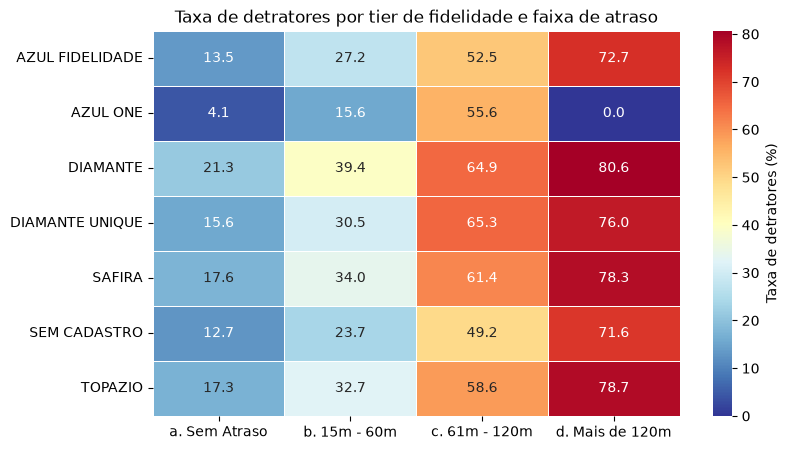

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.heatmap(
    tabela_taxa.mul(100), annot=True, fmt=".1f", cmap="RdYlBu_r",
    linewidths=0.6, linecolor="white", ax=ax,
    cbar_kws={"label": "Taxa de detratores (%)"},
)
ax.set_title("Taxa de detratores por tier de fidelidade e faixa de atraso")
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()